# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 2. Градиентный спуск своими руками

### Общая информация

Дата выдачи: 09.02.2026

Мягкий дедлайн: 23.02.2026 23:59 MSK

Жесткий дедлайн: 01.03.2026 23:59 MSK


### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). **Максимально допустимая оценка за работу — 10 баллов + 0.5 за социальный бонус.**

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Формат сдачи

Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием, а также файлы `descents.py` и `linear_regression.py`. Сам ноутбук называйте в формате **homework-practice-02-gd-Username.ipynb**, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: 10.5


### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных модификаций градиентного спуска. В файле `descents.py` вам нужно будет реализовать несколько классов для различных вариаций градиентного спуска, а именно:
* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`


В файле `linear_regression.py` вам необходимо будет реализовать класс `CustomLinearRegression` для обучения линейной регрессии (и, разумеется, предсказания целевой переменной на основе обученной модели).


### Про предложенную архитектуру

Предложенная вам архитектура шаблонов написана по принципам SOLID: основная ее идея в том, что вы сможете использовать различные лоссы и оптимизаторы с одним и тем же кодом прочих классов, никак не изменяя и не переписывая методы классов, которые с оптимизаторами и лоссом взаимодействуют. Мы добиваемся этого при помощи выделения интерфейсов (в Python мы достигаем этого при помощи абстрактных классов, см дальше в заданиях) и выделения зон ответственности каждого класса.

Глобально в нашей архитектуре всего 4 интерфейса (некоторые из которых на самом деле сразу concrete классы), каждый из которых порождает одно семейство:
- `interfaces.LossFunction`
  - Классы, имплементирующие этот интерфейс, отвечают за одну конкретную функцию потерь, используемую при обучении, и всё, что меняется вместе с ней при её замене: подсчёт лосса, подсчет градиента и аналитическое решение (если есть, то добавляется в интерфейс соответствующим mixin-ом).
- `interfaces.LinearRegressionInterface`
  - Интерфейс обертки для модели линейной регрессии, контейнер, содержащий составные части (лосс-функцию и оптимизатор) и использующий их для выполнения содержательной работы.
- `interfaces.LearningRateSchedule`
 - Простенькое семейство расписаний, определяющих шаг обучения для каждой итерации
- `interfaces.AbstractOptimizer`.
  -  Классы, имплементирующие этот интерфейс, имплементируют конкретный алгоритм оптимизации и всё, что происходит в его процессе. Пользуются обёрткой линейной регрессии для доступа к данным и вызова расчетов, чтобы не зависеть напрямую от конкретных функций потерь и шедулеров шага обучения.

Концепция передачи маленьких объектов, отвечающих за свою маленькую зону ответственности внутрь более сложного объекта для выполнения ими составных частей работы называется Dependency Injection, и работает как раз за счет выделения зоны ответственности и опоры на интерфейс вместо реализации.

Посмотрите на код `linear_regression.CustomLinearRegression`: она принимает в себя объекты с интерфейсами `LossFunction` и `AbstractOptimizer`, а в `descents.BaseDescent` как уточнении интерфейса абстрактного оптимизатора до итеративных оптимизаторов видно, что он в свою очередь принимает при инициализации объект шедулера шага обучения.

Благодаря этому, код, который использует эти классы, может по очереди:
- Инициализировать нужный шедулер с нужными параметрами для задания шага обучения
- Иницализировать оптимизатор, задав ему нужные параметры процесса и передав готовый шедулер
- Инициализировать класс линейной регрессии нужной под задачу функцией потерь и уже готовым оптимизатором.
- Запустить процесс обучения

И на любом этапе можно использовать другой объект с подходящим интерфейсом, и всё будет работать!


**В ходе выполнения этой домашки вы наполните все эти семейства классов различными имплементациями и будете менять их на ходу как перчатки!**

Более подробно про наследование классов в Python можно прочитать здесь:
* Наследование: https://docs.python.org/3/tutorial/classes.html#inheritance
* Абстрактные классы: https://docs.python.org/3/library/abc.html



## Задание 1. Линейная регрессия  (1 балл)

### Градиент функции потерь MSE

На семинаре про [матрично-векторное дифференцирование](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem03-vector-diff.pdf) вы должны были обсуждать дифференцирование функции потерь MSE в матричном виде.

### Задание 1.0. Градиент MSE в матричном виде (0.3 балла).

Напомним, что функция потерь MSE записывается как:

$$
    Q(w) = \frac{1}{\ell} \sum \limits_{i = 1}^\ell (y_i - \langle x_i, w \rangle)^2 = \frac{1}{\ell} \| X w - y \|^2
$$

где $\ell$ – количество объектов в выборке, $X \in \mathbb{R}^{\ell \times d}$ – матрица "объект-признак", а $y \in \mathbb{R}^\ell$ – целевая переменная. Через $x_i$ обозначается $i$-ая строчка матрицы $X$, отвечающая за $i$-й объект выборки.

- **Выпишите ниже (подсмотрев в семинар или решив самостоятельно) градиент для функции потерь MSE в матричном виде.**

**Решение:**

Домножим MSE на $l$

$$     ||X(w+h)-y||^2 - ||Xw-y||^2 = \langle X(w+h) - y, X(w+h) - y \rangle - \langle Xw - y, Xw - y \rangle = \langle Xh, Xw - y\rangle + \langle Xw - y, Xh \rangle + \langle Xh, Xh\rangle = 2 \langle Xh, Xw - y\rangle + \langle Xh, Xh\rangle = 2 \langle h, X^T(Xw-y) \rangle + \langle Xh, Xh \rangle = \langle 2X^T(Xw-y), h \rangle + \langle Xh, Xh \rangle$$

Правая часть не зависит линейно от приращения $\Rightarrow \nabla Q(w) = \frac{2}{l}X^T(Xw-y)$


- **Имплементируйте методы `MSELoss.loss`, `MSELoss.gradient`**





### Задание 1.1 Аналитическое решение и `CustomLinearRegression` (0.7 балла)

Перед тем, как мы углубимся в итеративные методы оптимизации, давайте вспомним, что для ряда функций потерь существует и аналитическое решение. Давайте сперва вспомним, как оно выглядит для MSE.

- **Выведите формулу оптимальных $w$ в задаче минимизации MSE, и запишите её ниже.**

Вычислим гессиан MSELoss, то есть дифференциал $d_wf[h_1, h2]$

$$\frac{2}{l}\langle X^T(X(w+h_2) - y), h_1 \rangle - \frac{2}{l} \langle X^T(Xw - y), h_1 \rangle = \frac{2}{l}\langle X^TXh_2, h_1 \rangle = \frac{2}{l}\langle Xh_2, Xh_1 \rangle$$

Квадратичная норма неотрицательно определена, так как $\frac{2}{l}\langle Xh, Xh \rangle = \frac{2}{l}||Xh||^2 \ge 0$

в точке $w = (X^TX)^{-1}X^Ty$ значение $\nabla Q(w) = \frac{2}{l}X^T(Xw - y) = \frac{2}{l}(X^TX(X^TX)^{-1}X^Ty - X^Ty) = \frac{2}{l}(X^Ty - X^Ty) = 0$

- **Имплементируйте подсчет этого решения в `MSELoss._plain_analytic_solution`**

$$\text{MSE} = \| X w - y \|^2$$
$$ w = (X^TX)^{-1}X^Ty$$

**Вопрос**: Как мы помним, у аналитического решения есть минусы - какие?

**Ответ**: ассимптотическая сложность вычисления аналиитического решения $O(d^3 + d^2l)$, что очень долго работает на больших данных

Теперь прокинем это решение в наш класс линейной регрессии, чтобы получше разобраться в архитектуре.


- **Допишите класс `descents.AnalyticSolutionOptimizer`**
- **Допишите класс `CustomLinearRegression`**
  - В нем на текущем этапе нужно имплементировать все методы: `fit` и `predict` вам понадобятся прямо сейчас, а `compute_gradients` и `compute_loss` в следующей части.

Помните, про разделение ответственности классов!

За контроль процесса обучения отвечает оптимизатор, а объект линейной регрессии по факту выступает точкой входа, контейнером для данных и способом доступа к вычислениям, на основе которых оптимизатор принимает решения (e.g. значение антиградиента в точке весов).

При этом сам по себе оптимизатор должен быть универсален, в нем никак не должны содержаться детали, связанные с конкретными функциями потерь, все необходимое от них он может получить через `self.model`.

Аналогично, класс линейной регрессии тоже должен быть универсальным и готовым к работе с любыми лоссами и оптимизаторами, исполняющими заявленный интерфейс. Здесь применена dependency injection, и вы должны грммотно ее поддержать в своей имплементации. Аналогично, все, что вам может быть нужно от функций потерь, вы можете получить при помощи обращения к переданному объекту.

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import numpy as np
from linear_regression import MSELoss, CustomLinearRegression, AnalyticSolutionOptimizer

num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [4]:
from sklearn.metrics import mean_squared_error as mse
import sklearn.linear_model

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.09078611163840254
Your MSE 0.09078611163840251


Давайте сделаем задание немного прикольнее и изменим одну из колонок. Как мы знаем, полная мультиколлинеарность запрещает нам пользоваться аналитическим решением, но `sklearn` по какой-то причине это обходит, хмм

In [5]:
x[:, 3] = x[:, 2] + x[:, 4]

In [6]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.09578161251197828
Your MSE 1.1959145621409961


Ваша задача - понять, как можно сделать так, чтобы аналитическое решение работало всегда, вне зависимости от матрицы X. Как оказывается, это можно сделать, если воспользоваться SVD разложением. Для имплементации воспользуйтесь `scipy.sparse.linalg.svds`.

- Выведите через SVD формулу оптимальных $w$ в задаче минимизации MSE.

- Имплементируйте подсчет этого решения в `MSELoss._svd_analytic_solution`
    - Мир итерационных агоритмов причудлив. Если вы посмотрите на опции солверов svds, то увидите, что возможности вычислить точно все сингулярные числа вам не дают (propack рандомизированный и даст вам неточные ответы). Используйте стандартный солвер, выставьте максимальную доступную точность.

- Ответьте на **вопрос на засыпку**. Вообще говоря, в ряде случаев (например в нашем), даже такая неабсолютная на первый взгляд точность все равно позволяет получить точное решение задачи. Обоснуйте, почему? Как называется такой вид SVD? Какого минимального числа сингулярных чисел с вероятностью 1 будет достаточно в нашем случае для получения точного решения? Обоснуйте, почему.


$$\text{X} = \underset{n\times m}{\mathrm{U}} \ \underset{m\times m}{\mathrm{\Sigma}} \ \underset{m\times k}{\mathrm{V^T}}$$

$$ w = V \Sigma^{-1} U^T y $$

где $\Sigma^{-1}$ состоит из сингулярных значений $\frac{1}{\sigma_i}$, если $\sigma_i > 0$, иначе на его месте останется 0

$$\nabla Q(w) = 2X^T(Xw - y) = 2V\Sigma U^T(U\Sigma V^T w - y) = 2V\Sigma^2 V^T w - 2V\Sigma U^T y = 2V\Sigma(\Sigma V^T w - U^T y)$$

что для того, чтобы $\nabla Q(w) = 0$ достаточно, чтобы $\Sigma V^T w - U^T y = 0$, то есть когда $w = V\Sigma^{-1}U^Ty$

**Ответ**: В обычном SVD матрицу $\Sigma$ можно представить как
$$
\Sigma = \begin{pmatrix}
\sigma_1 & 0 & \ldots & \ldots & \ldots & 0 \\
0 & \sigma_2 & 0 & \ldots & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \sigma_r & \vdots & \vdots \\
0 & \vdots & \vdots & \vdots & \vdots & 0
\end{pmatrix} = \underbrace{\begin{pmatrix}
1 & 0 & \ldots & 0 \\
0 & 1 & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots\\
\vdots & \vdots & \vdots & 1\\
0 & \vdots & \vdots & 0
\end{pmatrix}}_{I_l} \cdot \underbrace{\begin{pmatrix}
\sigma_1 & & & \\
 & \sigma_2 & & \\
& & \ddots & \\
& & & \sigma_r
\end{pmatrix}}_{=\Sigma_r} \cdot \underbrace{\begin{pmatrix}
1 & 0 & \ldots & \ldots & \ldots & 0 \\
0 & 1 & 0 & \ldots & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & \vdots & \vdots & 1 & \vdots & 0
\end{pmatrix}}_{I_r}
$$

Пусть $U_r = UI_l, V_r = VI_r^T$. Столбцы матриц $U_r$ и $V_r$ все также ортогональны. Тогда $X = U\Sigma V^T = \underbrace{UI_l}_{=U_r} \Sigma_r \underbrace{I_rV}_{=V_r} = U_r \Sigma_r V_r$, где матрица $\Sigma_r$ квадратная положительная матрица

 Это усеченное SVD. Нужно $rk\ X$ сингулярных чисел, так как если их больше, то последние сингулярные числа равны 0, то есть занулят последние векторы из столбцов $U$. А если меньше, то потеряем сингулярные числа $>0$

In [7]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"

Sklearn MSE 0.09578161251197828
Your MSE 0.09578161251197827


## Задание 2. Реализация градиентного спуска (4 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`. При помощи них мы будем искать итеративные решения, подавая оптимизаторы внутрь нашей `CustomLinearRegression`.

### Напоминание про градиентный спуск

Основное свойство антиградиента &ndash; он указывает в сторону *наискорейшего* убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь $\eta_{k}$ обозначает длину шага на $k$-ой итерации (learning rate), а $Q(w)$ - функцию потерь (loss function).

Градиент для MSE вы уже нашли выше

### Задание 2.0. Learning Rate Schedules (0.2 балла)

Обратите внимание на **абстрактный** класс `LearningRateSchedule` в файле `descents.py`. С помощью его имплементаций мы на каждой итерации градиентного спуска будем получать соответствующий `learning_rate` $\eta_k$.

В файле уже реализован класс `ConstantLR`, который на каждой итерации возвращает один и тот же заранее заданный шаг. **Ваша задача в этом пункте – реализовать `TimeDecayLR`**, который мы будем использовать для обучения линейной регрессии. Формула очередного шага должна выглядеть следующим образом:
$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Задание 2.1. Родительский класс BaseDescent (1 балл).


Внимательно изучите устройство класса `BaseDescent`. У него есть один непомеченный абстрактным метод, который ему как частичному наследнику абстрактного класса нужно имплементировать - это `optimize`. В
этом методе необходимо имплементировать основной цикл обучения, и далее его будут переиспользовать все его наследники.

- **Допишите метод `BaseDescent.optimize`**


Для этого и всех дальнейших заданий необходимо соблюдать следующие условия:

* **Все вычисления должны быть векторизованы;**
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `_update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `CustomLinearRegression.loss_history`, в нём будем хранить *значения функции потерь до каждого шага, начиная с нулевого* (до первого шага по антиградиенту) и *значение функции потерь после оптимизации*.


Обратите внимание, что метод `_update_weights` всё ещё является абстрактным - его все ещё должны будут имплементировать дальнейшие наследники; фактически, только способом обновления весов они и отличаются. Она должна должна обновлять веса модели `self.model.w`, а также возвращать величину обновления $w_{k + 1} - w_k$.

Также обратите внимание на атрибут `self.iteration`, отвечающий за номер итерации алгоритма спуска. Как раз с помощью него (и `self.lr_schedule`) мы и будем получать `learning_rate` на соответствующей итерации алгоритма.

**Обратите внимание**

*да, в третий раз*

Все реализуемые вами классы спуска в задании - это *универсальные* оптимизаторы. Они не должны считать градиенты конкретной функции потерь внутри себя.

Для вычисления градиента они всегда обращаются к модели, с которой работают:

```
gradient = self.model.compute_gradients(X_batch, y_batch)
```

### Задание 2.2. Полный градиентный спуск VanillaGradientDescent (0.6 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Напомним, что шаг классического градиентного спуска выглядит следующим образом:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

**Важно**: Здесь и далее функция `_update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса модели `model.w`.

### Напоминание про SGD (стохастических градиентный спуск)

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов, обычно называемое **батчом**.

Оценка $\frac{1}{|B|} \sum \limits_{i \in B} \nabla_w q_i(w_k)$ называется **стохастическим градиентом** функции потерь, а получившийся метод называют методом **стохастического градиентного спуска** или просто SGD.

### Задание 2.3. Стохастический градиентный спуск StochasticGradientDescent (0.7 балла).

Реализуйте стохастический градиентный спуск, заполнив пропуски в классе `StochasticGradientDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться **гиперпараметром** метода и передаваться в конструктор класса `__init__(...)`. Семплировать индексы батча объектов $B$ можно с повторениями (через np.random.randint) - это допустимо и даёт несмещённую оценку градиента. По желанию можно без повторений (np.random.choice(..., replace=False) или через пермутацию по эпохам).

### Задание 2.4 Stochastic Average Gradient (0.6 балла)

Держим память последних индивидуальных градиентов $g_i$ по всем объектам и их среднее $\bar g = \frac{1}{\ell}\sum_i g_i$. На каждом шаге выбираем индексы $j$ (мини-батч), заново считаем $g_j^{new}(w_k)$, обновляем среднее:
$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr),\qquad
w_{k+1} = w_k - \eta_k \bar g.
$$
Инициализация: $g_i=0 \Rightarrow \bar g=0$.

Так получаем шаг почти как у полного градиента, но считаем градиент лишь на нескольких объектах за итерацию.

Реализуйте класс `SAGDescent` в `descents.py` с хранением `grad_memory` и `avg_grad`. Подсказка: чтобы получить пер-объектный градиент, можно вызывать `compute_gradients` на срезе из одного объекта `X[j:j+1]` или на фильтрованной индексами матрице для батча.

**Имейте в виду, что SAG достаточно капризный**: для его сходимости (и ее скорости) достаточно важен размер батча. Для вас установлено дефолтное значение, но на реальных данных его может быть недостаточно. В сравнениях методов ниже вам может понадобится подобрать значение размера батча, чтобы раскрыть потенциал метода. То ж касается и SGD, но в меньшей степени.

### Напоминание про метод инерции (или метод моментов)

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация (например, в случае **стохастического градиентного спуска**). Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 2.5 Метод Momentum - MomentumDescent (0.5 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ являеться гиперпараметром метода, однако в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Напоминание про AdaGrad, RMSprop и Adam

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. Идея проста: мы будем "копить" сумму квадратов градиентов и делить очередной градиент на корень из этой суммы. Таким образом, обновление весов с большими градиентами будет тормозиться, а с маленькими наоборот получать большие шаги. Формула обновлени будет выглядить так:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций (метод инерции), а также делать адаптивную длину шага по каждому параметру (`RMSProp`). Таким образом, мы получим метод `Adam` с той лишь разницей, что в методе `Adam` дополнительно делается нормировка накопленных градиентов и квадратов градиентов для устранения смещения.

### Задание 2.6. Метод Adam (Adaptive Moment Estimation) (0.4 балла).

Реализуйте градиентный спуск с методом Adam, заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 3. Проверка кода (0 баллов)

Данная секция нужна для того, чтобы убедиться в правильности реализации методов спуска и класса `CustomLinearRegression`. В начале мы сделаем небольшую локальную проверку на "адекватность" и "запускаемость" ваших моделей, после чего уже можно будет делать посылки в Яндекс Контест.

In [8]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [10]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

Проверяем код на запускаемость.

In [11]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в [Яндекс Контесте](https://new.contest.yandex.ru/contests/90083/start).

Для каждой задачи из контеста вставьте ID успешной посылки и ваш ник (почту):

* **Ник/почта**: fagrek@edu.hse.ru


* **VanillaGradientDescent**: 157492427


* **StochasticGradientDescent**: 157492434


* **SAGDescent**: 157492440


* **MomentumDescent**: 157492388


* **Adam**: 157492443


* **LinearRegression**: 157492415

## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [12]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

In [13]:
data = pd.read_csv('autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [14]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


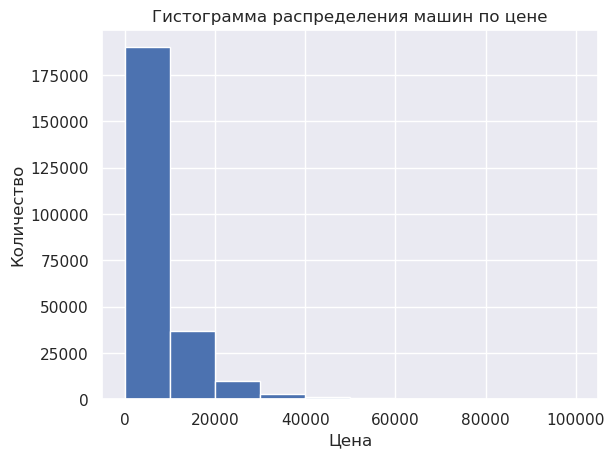

In [15]:
plt.hist(data['price'])
plt.title('Гистограмма распределения машин по цене')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.show()

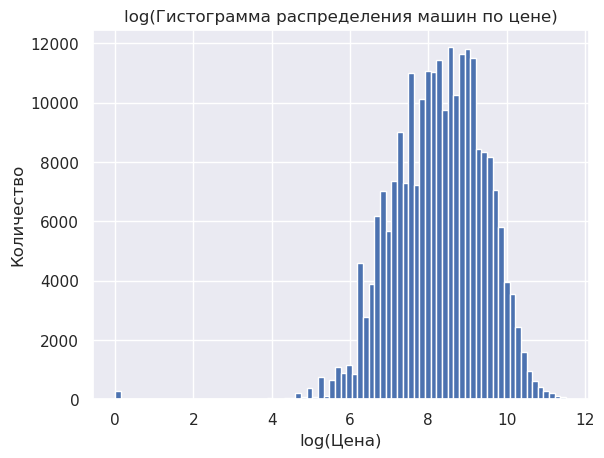

In [16]:
plt.hist(np.log(data['price']), bins=80)
plt.title('log(Гистограмма распределения машин по цене)')
plt.xlabel('log(Цена)')
plt.ylabel('Количество')
plt.show()

Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

Удалено записей по цене: 3072


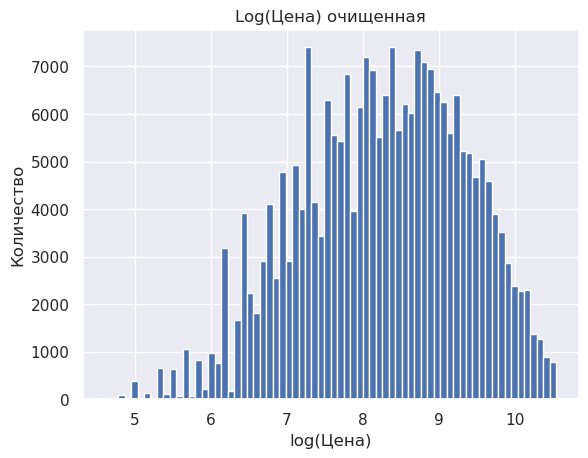

In [17]:
df = data.copy()
low_price_bound = 100
high_price_bound = df['price'].quantile(0.99)

df_clean = df[(df['price'] > low_price_bound) & (df['price'] < high_price_bound)].copy()
print(f"Удалено записей по цене: {len(df) - len(df_clean)}")

df_clean['price_log'] = np.log(df_clean['price'])

plt.hist(df_clean['price_log'], bins=70)
plt.title('Log(Цена) очищенная')
plt.xlabel('log(Цена)')
plt.ylabel('Количество')
plt.show()

Разделите признаки на категориальные, числовые и ... все остальное

In [18]:
names = list(data.columns)

categorical = names[:6]
numeric = names[6:9]
other = []

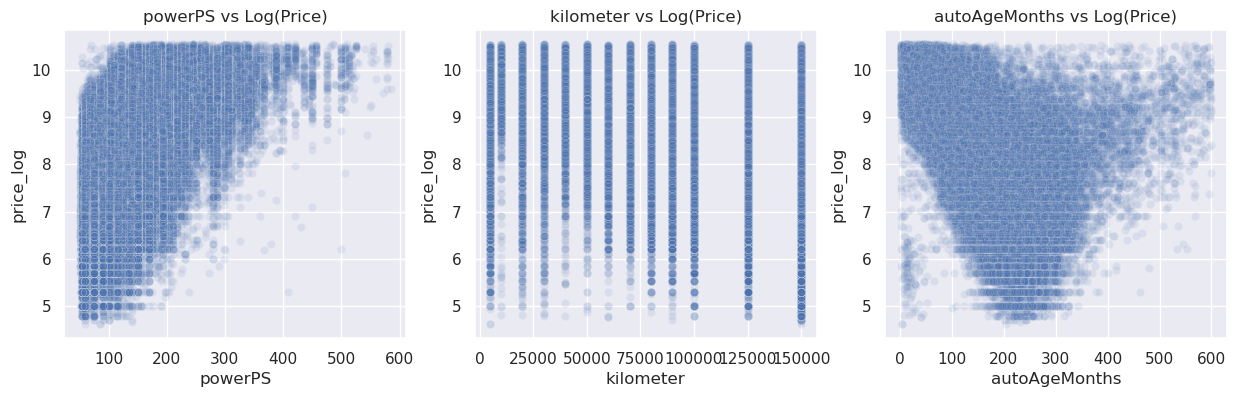

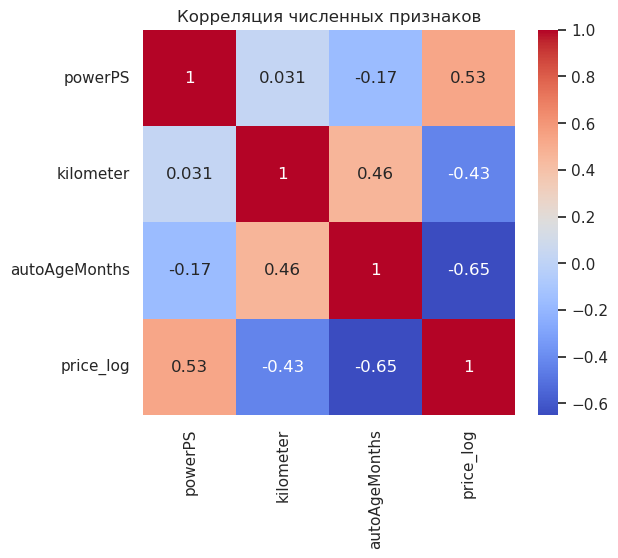

In [19]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df_clean[col], y=df_clean['price_log'], alpha=0.1)
    plt.title(f'{col} vs Log(Price)')
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(df_clean[numeric + ['price_log']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция численных признаков')
plt.show()

Добавляем в данные единичную колонку `bias`, чтобы не делать отдельные параметр $b$ для свободного члена модели.

In [20]:
df_clean['bias'] = 1
other = ['bias']

x = df_clean[categorical + numeric + other]
y = df_clean['price_log']

Теперь вам необходимо разбить данные на обучающую, тестовую и валидационную выборки.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size = 0.2, random_state = 10)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=10)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (190494, 10)
Размер валидационной выборки: (23812, 10)
Размер тестовой выборки: (23812, 10)


А также сделаем базовую обработку данных, а именно:
* Применим `OneHotEncoding` к категориальным признакам
* Стандартизуем численные признаки с помощью `StandardScaler`
* Остальные признаки трогать не будем, т.к. с ними непонятно что делать

> А почему мы сначала делим данные, а только потом применяем обработку данных? Энкодеры и скейлеры используют информацию о данных: если сделать fit на всем датасете до split, это будет утечка: статистики из val/test попадут в обучение.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

X_train = column_transformer.fit_transform(X_train)
X_val = column_transformer.transform(X_val)
X_test = column_transformer.transform(X_test)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

## Задание 5. Сравнение методов градиентного спуска (1.5 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (0.75 балла)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [23]:
from sklearn.metrics import r2_score, mean_squared_error

lambdas = np.logspace(-5, 0, 6)

results = []

for descent_model in descent_models:
    best_val_mse = float('inf')
    best_stats = None

    for lam in lambdas:
        lr_schedule = TimeDecayLR(lam)
        optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
        model.fit(X_train, y_train_np)
        pred_val = model.predict(X_val)
        val_mse = mean_squared_error(y_val_np, pred_val)

        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        if (val_mse < best_val_mse):
            best_val_mse = val_mse
                
            pred_train = model.predict(X_train)
            pred_test = model.predict(X_test)
            
            train_mse = mean_squared_error(y_train_np, pred_train)
            test_mse = mean_squared_error(y_test_np, pred_test)
            train_r2 = r2_score(y_train_np, pred_train)
            test_r2 = r2_score(y_test_np, pred_test)
            
            iters = len(model.loss_history) - 1

            best_stats = {
                    'Method': descent_model.__name__,
                    'Best Lambda': lam,
                    'Train MSE': train_mse,
                    'Val MSE': val_mse,
                    'Test MSE': test_mse,
                    'Train R2': train_r2,
                    'Test R2': test_r2,
                    'Iterations': iters
                }
    results.append(best_stats)

results_df = pd.DataFrame(results)
display(results_df)


,Method,Best Lambda,Train MSE,Val MSE,Test MSE,Train R2,Test R2,Iterations
0,VanillaGradientDescent,1.0,0.283578,0.301349,0.275164,0.761369,0.766632,377
1,StochasticGradientDescent,0.1,0.346655,0.361168,0.337779,0.708289,0.713529,924
2,SAGDescent,1.0,1.206007,1.223568,1.191250,-0.014856,-0.010303,1000
3,MomentumDescent,1.0,0.260503,0.277983,0.254021,0.780786,0.784564,821
4,Adam,1.0,0.255331,0.273603,0.248121,0.785139,0.789568,1000


### Задание 5.2. Сравнение методов (0.75 балла)

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_179436/1186170920.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(range(len(loss_history)), loss_history, label=f"{descent_name} ($\lambda$={lam:.1e})", linewidth=2)


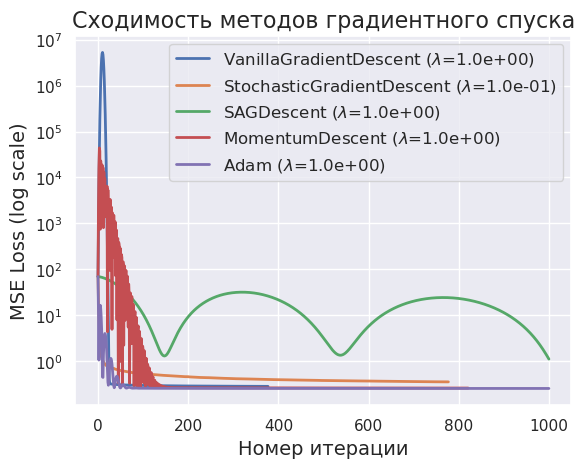

In [24]:
for descent_model in descent_models:
    descent_name = descent_model.__name__
    lam = results_df.loc[results_df['Method'] == descent_name, 'Best Lambda'].values[0]
    lr_schedule = TimeDecayLR(lambda_=lam)
    optimizer = descent_model(lr_schedule)
    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(X_train, y_train_np)
    loss_history = model.loss_history
    plt.plot(range(len(loss_history)), loss_history, label=f"{descent_name} ($\lambda$={lam:.1e})", linewidth=2)

plt.title("Сходимость методов градиентного спуска", fontsize=16)
plt.xlabel("Номер итерации", fontsize=14)
plt.ylabel("MSE Loss (log scale)", fontsize=14)
plt.yscale("log")
plt.legend(fontsize=12)
plt.show()

## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска.

* Сделайте по несколько запусков (например, $k = 10$) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

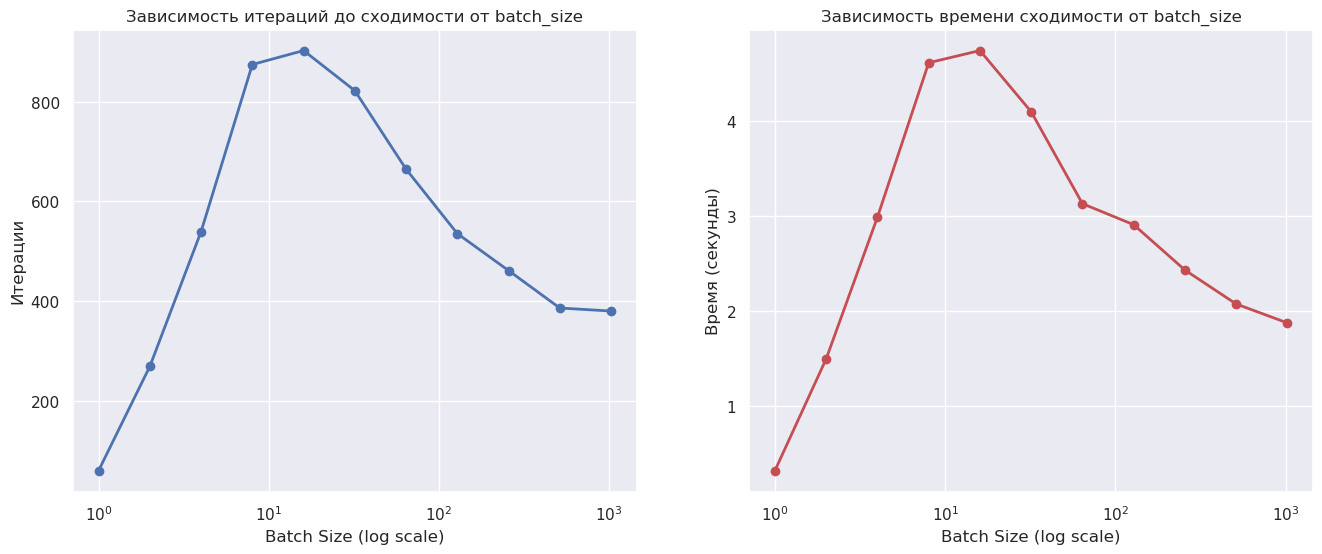

In [25]:
import time

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
k = 10

lam = 0.1
avg_times = []
avg_iters = []
for bs in batch_sizes:
    times = []
    iters = []
    
    for _ in range(k):
        lr_schedule = TimeDecayLR(lambda_=lam)
        
        optimizer = StochasticGradientDescent(lr_schedule=lr_schedule, batch_size=bs)
        
        model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
        
        start_time = time.time()
        model.fit(X_train, y_train_np)
        end_time = time.time()
        
        times.append(end_time - start_time)
        iters.append(len(model.loss_history) - 1)
        
    avg_times.append(np.mean(times))
    avg_iters.append(np.mean(iters))

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(batch_sizes, avg_iters, marker='o', linewidth=2, color='b')
plt.xscale('log')
plt.title('Зависимость итераций до сходимости от batch_size')
plt.xlabel('Batch Size (log scale)')
plt.ylabel('Итерации')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(batch_sizes, avg_times, marker='o', linewidth=2, color='r')
plt.xscale('log')
plt.title('Зависимость времени сходимости от batch_size')
plt.xlabel('Batch Size (log scale)')
plt.ylabel('Время (секунды)')
plt.grid(True)

plt.show()

**Выводы:**

Возможно маленькие батчсайзы плохо сходятся(может быть появляется Nan). Большие батчсайзы быстрее сходятся по итерациям, возможно настолько быстро, что и по времени быстрее

## Задание 7. Регуляризация (0.5 балла)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация – это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать $L_2$-регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Допишите класс `linear_regression.L2Regularization`, следуя интерфейсу и докуметации.

Используя регуляризованный лосс в эксприментах, найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравните для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего должно получиться 5 графиков).

Посмотрите на получившиеся результаты. Какие можно сделать выводы, как регуляризация влияет на сходимость? Как изменилось качество на обучающей выборке? На тестовой? Чем вы можете объяснить это?

In [32]:
from linear_regression import L2Regularization

lambdas = np.logspace(-4, 0, 5)
mus = np.logspace(-4, 1, 6)

results_reg = []
best_models_reg = {} 

for descent_model in descent_models:
    best_val_mse = float('inf')
    best_stats = None
    for mu in mus:
        for lam in lambdas:
            lr_schedule = TimeDecayLR(lam)
            loss_func = L2Regularization(core_loss=MSELoss(), mu_rate=mu)
            optimizer = descent_model(lr_schedule=lr_schedule)

            model = CustomLinearRegression(optimizer=optimizer, loss_function=loss_func)
            model.fit(X_train, y_train_np)
            pred_val = model.predict(X_val)
            val_mse = mean_squared_error(y_val_np, pred_val)

            if np.isnan(val_mse) or np.isinf(val_mse):
                continue

            if (val_mse < best_val_mse):
                best_val_mse = val_mse
                    
                pred_train = model.predict(X_train)
                pred_test = model.predict(X_test)
                
                train_mse = mean_squared_error(y_train_np, pred_train)
                test_mse = mean_squared_error(y_test_np, pred_test)
                train_r2 = r2_score(y_train_np, pred_train)
                test_r2 = r2_score(y_test_np, pred_test)
                
                iters = len(model.loss_history) - 1

                best_stats = {
                        'Method': descent_model.__name__,
                        'Best Lambda': lam,
                        'Best Mu': mu,
                        'Train MSE': train_mse,
                        'Val MSE': val_mse,
                        'Test MSE': test_mse,
                        'Train R2': train_r2,
                        'Test R2': test_r2,
                        'Iterations': iters
                    }
                best_models_reg[descent_model.__name__] = model
    results_reg.append(best_stats)

df_reg = pd.DataFrame(results_reg)
display(df_reg)

,Method,Best Lambda,Best Mu,Train MSE,Val MSE,Test MSE,Train R2,Test R2,Iterations
0,VanillaGradientDescent,1.0,0.0001,0.283654,0.301419,0.275233,0.761305,0.766574,375
1,StochasticGradientDescent,0.1,0.0001,0.338309,0.353791,0.328556,0.715313,0.721351,998
2,SAGDescent,1.0,0.1000,0.828750,0.840362,0.815583,0.302606,0.308302,1000
3,MomentumDescent,1.0,0.0001,0.260818,0.278303,0.254297,0.780521,0.784330,774
4,Adam,1.0,0.0001,0.256394,0.274592,0.249931,0.784245,0.788033,1000


<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_179436/2854377478.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(model_no_reg.loss_history, label=f"No Reg ($\lambda$={best_lam_no_reg:.1e})", color='blue', linestyle='--')
/tmp/ipykernel_179436/2854377478.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(model_reg.loss_history, label=f"L2 Reg ($\lambda$={best_lr:.1e}, $\mu$={best_mu:.1e})", color='red')
/tmp/ipykernel_179436/2854377478.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(model_reg.loss_history, label=f"L2 Reg ($\lambda$={best_lr:.1e}, $\mu$={best_mu:.1e})", color='red')


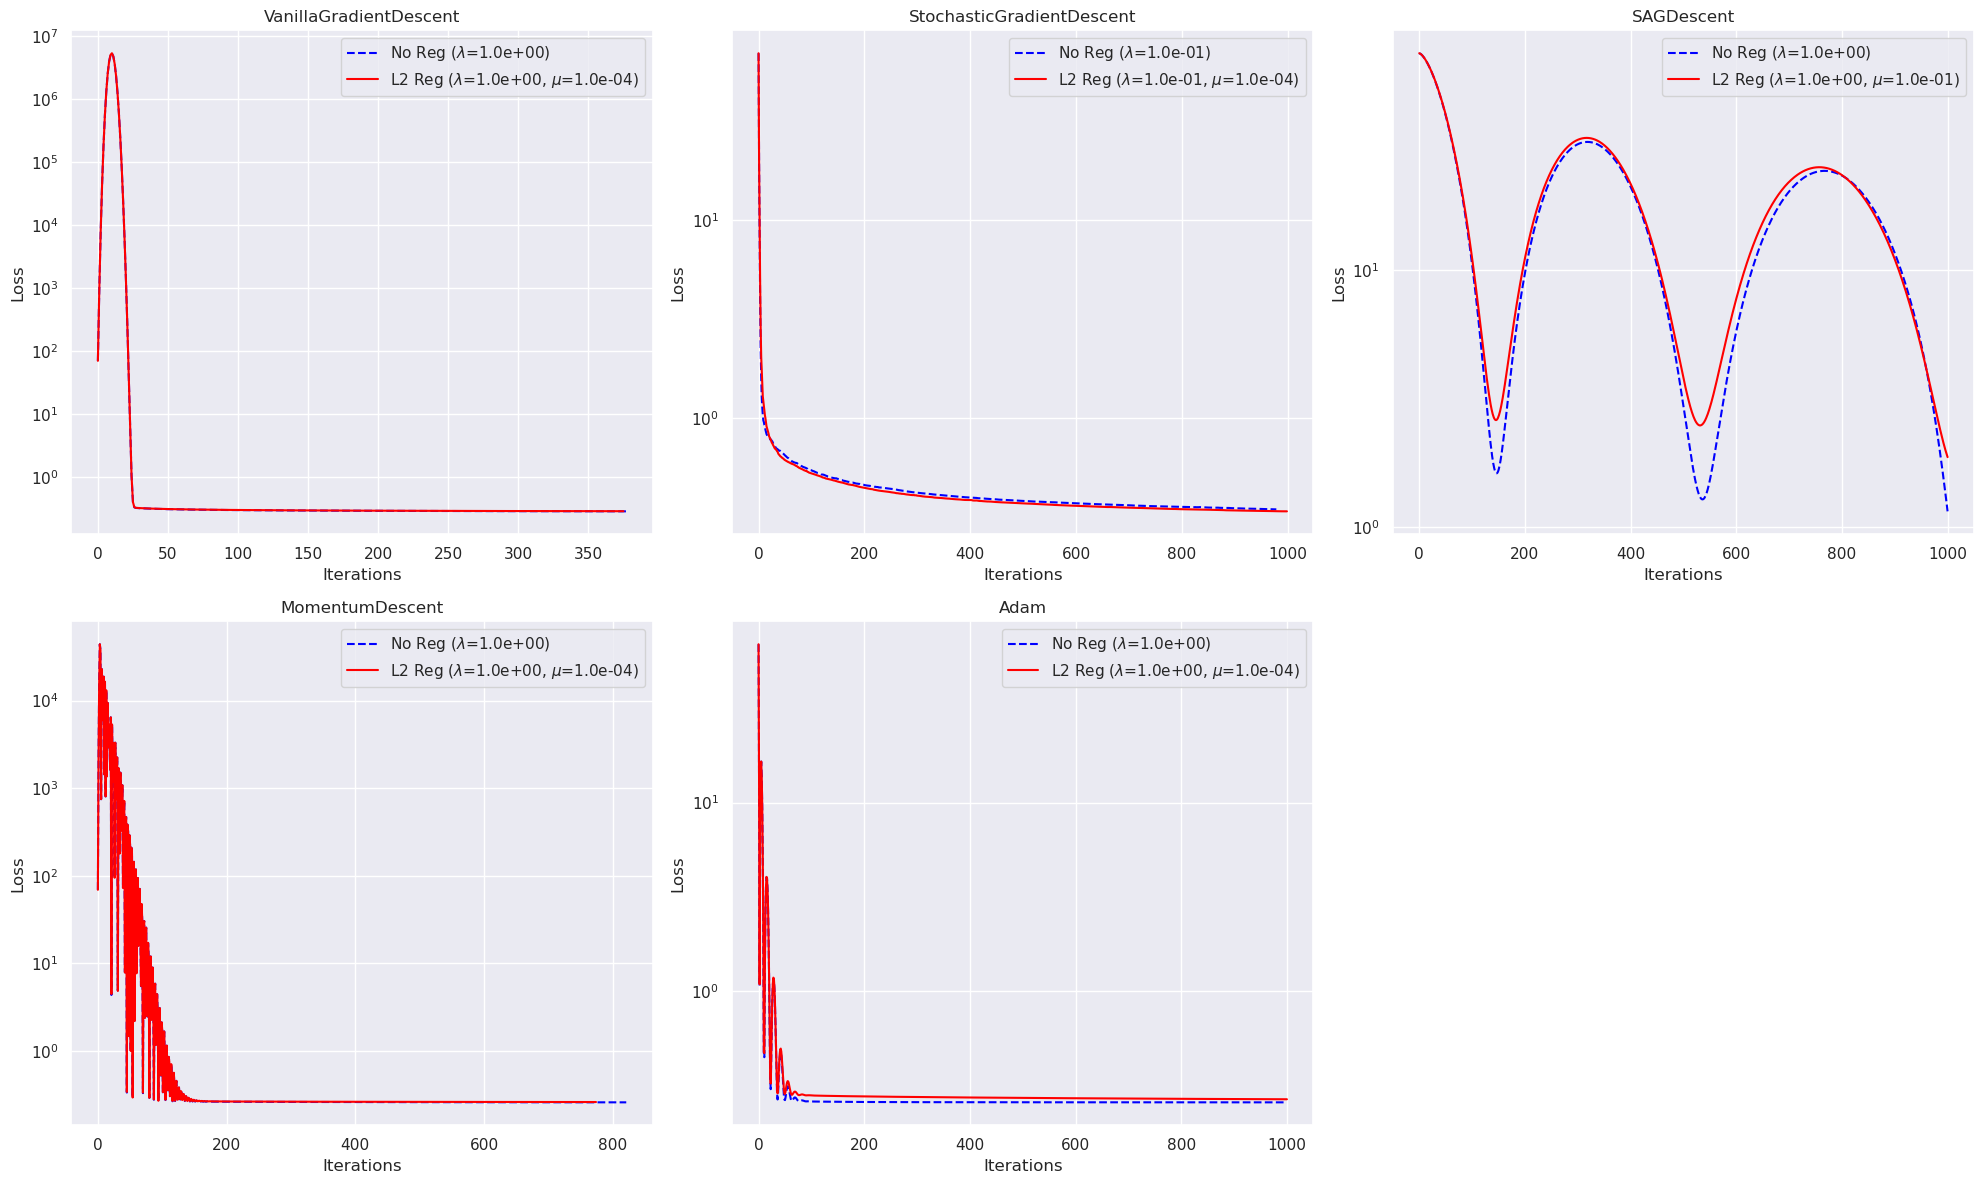

In [33]:
plt.figure(figsize=(20, 12))
for i, descent_model in enumerate(descent_models):
    method_name = descent_model.__name__
    plt.subplot(2, 3, i+1)
    
    best_lam_no_reg = results_df.loc[results_df['Method'] == method_name, 'Best Lambda'].values[0]
        
    optimizer_no_reg = descent_model(lr_schedule=TimeDecayLR(lambda_=best_lam_no_reg))
    model_no_reg = CustomLinearRegression(optimizer=optimizer_no_reg, loss_function=MSELoss())
    model_no_reg.fit(X_train, y_train_np)
    
    plt.plot(model_no_reg.loss_history, label=f"No Reg ($\lambda$={best_lam_no_reg:.1e})", color='blue', linestyle='--')

    model_reg = best_models_reg[method_name]
    best_lr = df_reg.loc[df_reg['Method'] == method_name, 'Best Lambda'].values[0]
    best_mu = df_reg.loc[df_reg['Method'] == method_name, 'Best Mu'].values[0]
    
    plt.plot(model_reg.loss_history, label=f"L2 Reg ($\lambda$={best_lr:.1e}, $\mu$={best_mu:.1e})", color='red')
    
    plt.title(method_name)
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
df_comp1 = results_df[['Method', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
df_comp1[['Train MSE Reg', 'Test MSE Reg', 'Train R2 Reg', 'Test R2 Reg', 'Iterations Reg']] = df_reg[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
display(df_comp1)

/tmp/ipykernel_179436/2953409260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp1[['Train MSE Reg', 'Test MSE Reg', 'Train R2 Reg', 'Test R2 Reg', 'Iterations Reg']] = df_reg[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]


,Method,Train MSE,Test MSE,Train R2,Test R2,Iterations,Train MSE Reg,Test MSE Reg,Train R2 Reg,Test R2 Reg,Iterations Reg
0,VanillaGradientDescent,0.283578,0.275164,0.761369,0.766632,377,0.283654,0.275233,0.761305,0.766574,375
1,StochasticGradientDescent,0.346655,0.337779,0.708289,0.713529,924,0.338309,0.328556,0.715313,0.721351,998
2,SAGDescent,1.206007,1.191250,-0.014856,-0.010303,1000,0.828750,0.815583,0.302606,0.308302,1000
3,MomentumDescent,0.260503,0.254021,0.780786,0.784564,821,0.260818,0.254297,0.780521,0.784330,774
4,Adam,0.255331,0.248121,0.785139,0.789568,1000,0.256394,0.249931,0.784245,0.788033,1000


**Вывод:**

С регулязацией немного быстрее сходится по итерациям. По графикам видно, что лосс чуть хуже

## Задание 8. Альтернативные функции потерь (1 балл)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **LogCosh** и **HuberLoss**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
   \frac{1}{2} (a_i - y_i)^2, & \text{если } |a_i - y_i| < \delta, \\
   \delta \cdot |a_i - y_i| - \frac{1}{2} \delta^2, & \text{если } |a_i - y_i| \geq \delta,
\end{cases}
$$

Самостоятельно продифференцируйте данные функции потерь чтобы найти их градиенты _(требуется показать не только результат, но и промежуточные вычисления)_:

**Решение:**

$$L(y, Xw) = \frac{1}{n} \sum_{i=1}^{n}\log\left(\cosh(X_i w - y_i)\right)$$

$\frac{d}{dx}\log(\cosh(x - y)) = \frac{1}{\cosh(x-y)}\sinh(x-y) = \tanh(x-y)$

$\frac{\partial(X_iw - y_i)}{\partial w} = X_i^T$

Тогда

$$\frac{\partial L(y, Xw)}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} \frac{\partial Xiw - y_i}{\partial w} \cdot \frac{d \log(\cos(x-y))}{dx} =\frac{1}{n} \sum_{i=1}^{n} X_i^T \tanh(X_iw - y) = \frac{1}{n}X^T @ \tanh(Xw-y)$$


Теперь будем считать Huber Loss

если $|a_i - y_i| < \delta$, то $\frac{d L_{Huber}(y_i, a_i)}{d a_i} = (a_i - y_i)$, иначе $\frac{d L_{Huber}(y_i, a_i)}{d a_i} = \delta \cdot sgn(a_i - y_i)$

Значит

$$\frac{\partial L_{Huber}(y, Xw)}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} \begin{cases}
   (X_iw - y_i), & \text{если } |Xw_i - y_i| < \delta, \\
   \delta \cdot sgn(Xw_i - y_i)& \text{если } |Xw_i - y_i| \geq \delta,
\end{cases}$$

Программно реализуйте функции потерь и их градиенты для LogCosh и HuberLoss в файле `linear_regression.py`. После этого обучите все пять методов градиентного спуска (без регуляризации) с этими лоссами аналогично заданию 5 и сравните качество с результатами из задания 5, где использовался MSE.

Имплементировать эти функции потерь необходимо при помощи наследования от `linear_regression.LossFunction` и имплементирования всех абстрактных методов. Аналитическое решение для этих функций выводить и имплементировать не требуется.



In [39]:
from linear_regression import LogCosh, HuberLoss

lambdas = np.logspace(-5, 0, 6)

result_alt1 = []

for descent_model in descent_models:
    best_val_mse = float('inf')
    best_stats = None
    for lam in lambdas:
        lr_schedule = TimeDecayLR(lam)
        loss_func = LogCosh()
        optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=loss_func)
        model.fit(X_train, y_train_np)
        pred_val = model.predict(X_val)
        val_mse = mean_squared_error(y_val_np, pred_val)

        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        if (val_mse < best_val_mse):
            best_val_mse = val_mse
                
            pred_train = model.predict(X_train)
            pred_test = model.predict(X_test)
            
            train_mse = mean_squared_error(y_train_np, pred_train)
            test_mse = mean_squared_error(y_test_np, pred_test)
            train_r2 = r2_score(y_train_np, pred_train)
            test_r2 = r2_score(y_test_np, pred_test)
            
            iters = len(model.loss_history) - 1

            best_stats = {
                    'Method': descent_model.__name__,
                    'Best Lambda': lam,
                    'Loss Function': 'LogCosh',
                    'Train MSE': train_mse,
                    'Val MSE': val_mse,
                    'Test MSE': test_mse,
                    'Train R2': train_r2,
                    'Test R2': test_r2,
                    'Iterations': iters
                }
    result_alt1.append(best_stats)

df_alt1 = pd.DataFrame(result_alt1)
display(df_alt1)

result_alt2 = []

for descent_model in descent_models:
    best_val_mse = float('inf')
    best_stats = None
    for lam in lambdas:
        lr_schedule = TimeDecayLR(lam)
        loss_func = HuberLoss(delta=1.0)
        optimizer = descent_model(lr_schedule=lr_schedule)

        model = CustomLinearRegression(optimizer=optimizer, loss_function=loss_func)
        model.fit(X_train, y_train_np)
        pred_val = model.predict(X_val)
        val_mse = mean_squared_error(y_val_np, pred_val)

        if np.isnan(val_mse) or np.isinf(val_mse):
            continue

        if (val_mse < best_val_mse):
            best_val_mse = val_mse
                
            pred_train = model.predict(X_train)
            pred_test = model.predict(X_test)
            
            train_mse = mean_squared_error(y_train_np, pred_train)
            test_mse = mean_squared_error(y_test_np, pred_test)
            train_r2 = r2_score(y_train_np, pred_train)
            test_r2 = r2_score(y_test_np, pred_test)
            
            iters = len(model.loss_history) - 1

            best_stats = {
                    'Method': descent_model.__name__,
                    'Best Lambda': lam,
                    'Loss Function': 'Huber Loss',
                    'Train MSE': train_mse,
                    'Val MSE': val_mse,
                    'Test MSE': test_mse,
                    'Train R2': train_r2,
                    'Test R2': test_r2,
                    'Iterations': iters
                }
    result_alt2.append(best_stats)

df_alt2 = pd.DataFrame(result_alt2)
display(df_alt2)

df_comp2 = results_df[['Method', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
df_comp2[['Train MSE LogCosh', 'Test MSE LogCosh', 'Train R2 LogCosh', 'Test R2 LogCosh', 'Iterations LogCosh']] = df_alt1[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
display(df_comp2)

df_comp3 = results_df[['Method', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
df_comp3[['Train MSE Huber', 'Test MSE Huber', 'Train R2 Huber', 'Test R2 Huber', 'Iterations Huber']] = df_alt2[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]
display(df_comp3)

,Method,Best Lambda,Loss Function,Train MSE,Val MSE,Test MSE,Train R2,Test R2,Iterations
0,VanillaGradientDescent,1.0,LogCosh,0.315205,0.335064,0.301781,0.734755,0.744059,362
1,StochasticGradientDescent,1.0,LogCosh,0.302797,0.323782,0.290099,0.745196,0.753966,1000
2,SAGDescent,1.0,LogCosh,69.329571,69.347987,69.245900,-57.340879,-57.727643,1
3,MomentumDescent,1.0,LogCosh,0.278625,0.300851,0.266129,0.765537,0.774295,690
4,Adam,1.0,LogCosh,0.263383,0.287124,0.250596,0.778363,0.787469,1000


,Method,Best Lambda,Loss Function,Train MSE,Val MSE,Test MSE,Train R2,Test R2,Iterations
0,VanillaGradientDescent,1.0,Huber Loss,0.312298,0.332855,0.298526,0.737201,0.746819,372
1,StochasticGradientDescent,1.0,Huber Loss,0.297936,0.319012,0.284677,0.749287,0.758565,1000
2,SAGDescent,1.0,Huber Loss,69.329640,69.348055,69.245973,-57.340938,-57.727704,1
3,MomentumDescent,1.0,Huber Loss,0.278642,0.301249,0.265886,0.765523,0.774501,715
4,Adam,1.0,Huber Loss,0.264397,0.288638,0.251141,0.777510,0.787006,1000


/tmp/ipykernel_179436/2479501882.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp2[['Train MSE LogCosh', 'Test MSE LogCosh', 'Train R2 LogCosh', 'Test R2 LogCosh', 'Iterations LogCosh']] = df_alt1[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]


,Method,Train MSE,Test MSE,Train R2,Test R2,Iterations,Train MSE LogCosh,Test MSE LogCosh,Train R2 LogCosh,Test R2 LogCosh,Iterations LogCosh
0,VanillaGradientDescent,0.283578,0.275164,0.761369,0.766632,377,0.315205,0.301781,0.734755,0.744059,362
1,StochasticGradientDescent,0.346655,0.337779,0.708289,0.713529,924,0.302797,0.290099,0.745196,0.753966,1000
2,SAGDescent,1.206007,1.191250,-0.014856,-0.010303,1000,69.329571,69.245900,-57.340879,-57.727643,1
3,MomentumDescent,0.260503,0.254021,0.780786,0.784564,821,0.278625,0.266129,0.765537,0.774295,690
4,Adam,0.255331,0.248121,0.785139,0.789568,1000,0.263383,0.250596,0.778363,0.787469,1000


/tmp/ipykernel_179436/2479501882.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp3[['Train MSE Huber', 'Test MSE Huber', 'Train R2 Huber', 'Test R2 Huber', 'Iterations Huber']] = df_alt2[['Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Iterations']]


,Method,Train MSE,Test MSE,Train R2,Test R2,Iterations,Train MSE Huber,Test MSE Huber,Train R2 Huber,Test R2 Huber,Iterations Huber
0,VanillaGradientDescent,0.283578,0.275164,0.761369,0.766632,377,0.312298,0.298526,0.737201,0.746819,372
1,StochasticGradientDescent,0.346655,0.337779,0.708289,0.713529,924,0.297936,0.284677,0.749287,0.758565,1000
2,SAGDescent,1.206007,1.191250,-0.014856,-0.010303,1000,69.329640,69.245973,-57.340938,-57.727704,1
3,MomentumDescent,0.260503,0.254021,0.780786,0.784564,821,0.278642,0.265886,0.765523,0.774501,715
4,Adam,0.255331,0.248121,0.785139,0.789568,1000,0.264397,0.251141,0.777510,0.787006,1000


### Кулинарно-социализационный бонус. (0.5 балла)

Как мы знаем, в феврале зима уже не объяснение, а обстоятельство непреодолимой силы - и лучший способ спорить с ней это поделиться теплом с друзьями и близкими. Выберите рецепт, который соответствует вашему настроению, приготовьте выбранное блюдо и угостите хотя бы одного человека им. Кратко опишите ваши впечатления, прикрепите рецепт и фотографии блюда и довольного гостя.

Угостил сестру пастой с курицей

Рецепт:
<img src = 'recept.jpg'>
Результат:
<img src = 'result.jpg'>
Оценка блюда:
<img src = 'rating.jpg'>

### Использование LLM:

я использовал Gemini 3 Pro для визуализации графиков